In [49]:
from sklearn.datasets import fetch_openml
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import lognorm
import warnings
import seaborn as sns
warnings.filterwarnings('ignore') 

from sklearn.metrics import mean_absolute_percentage_error, root_mean_squared_error, median_absolute_error
from sklearn.preprocessing import RobustScaler


from sklearn.model_selection import cross_val_score, KFold
from sklearn.tree import DecisionTreeRegressor
import matplotlib as mpl
from yellowbrick.model_selection import LearningCurve
from sklearn.model_selection import GridSearchCV


In [2]:
DATASET="machine_cpu"

## 1

In [3]:
dataset = fetch_openml(DATASET)
X = dataset.data
y = dataset.target

### Текстовое описание датасета

In [4]:
dataset.DESCR

'**Author**:   \n**Source**: Unknown -   \n**Please cite**:   \n\nThe problem concerns Relative CPU Performance Data. More information can be obtained in the UCI Machine\n Learning repository (http://www.ics.uci.edu/~mlearn/MLSummary.html).\n The used attributes are :\n MYCT: machine cycle time in nanoseconds (integer)\n MMIN: minimum main memory in kilobytes (integer)\n MMAX: maximum main memory in kilobytes (integer)\n CACH: cache memory in kilobytes (integer)\n CHMIN: minimum channels in units (integer)\n CHMAX: maximum channels in units (integer)\n PRP: published relative performance (integer) (target variable)\n \n Original source: UCI machine learning repository. \n Source: collection of regression datasets by Luis Torgo (ltorgo@ncc.up.pt) at\n http://www.ncc.up.pt/~ltorgo/Regression/DataSets.html\n Characteristics: 209 cases; 6 continuous variables\n\nDownloaded from openml.org.'

In [5]:
X.head()

,MYCT,MMIN,MMAX,CACH,CHMIN,CHMAX
0,125,256,6000,256,16,128
1,29,8000,32000,32,8,32
2,29,8000,32000,32,8,32
3,29,8000,32000,32,8,32
4,29,8000,16000,32,8,16


In [6]:
y.head()

0    198
1    269
2    220
3    172
4    132
Name: class, dtype: int64

Бизнес задача: основываясь на данных по времени цикла, объему оперативной памяти и тп параметрам определить относульную производительность основываясь на данных, которые были получены ранее.

Задача МО: обучить регрессионную модель для предсказания PRP основываясь на MYCT, MMIN, MMAX, CACH, CHMIN, CHMAX. 

## 2

Основная статистическая информация по данным:

In [7]:
X.describe()

,MYCT,MMIN,MMAX,CACH,CHMIN,CHMAX
count,209.000000,209.000000,209.000000,209.000000,209.000000,209.000000
mean,203.822967,2867.980861,11796.153110,25.205742,4.698565,18.267943
std,260.262926,3878.742758,11726.564377,40.628722,6.816274,25.997318
min,17.000000,64.000000,64.000000,0.000000,0.000000,0.000000
25%,50.000000,768.000000,4000.000000,0.000000,1.000000,5.000000
50%,110.000000,2000.000000,8000.000000,8.000000,2.000000,8.000000
75%,225.000000,4000.000000,16000.000000,32.000000,6.000000,24.000000
max,1500.000000,32000.000000,64000.000000,256.000000,52.000000,176.000000


In [8]:
y.describe()

count     209.000000
mean      105.622010
std       160.830733
min         6.000000
25%        27.000000
50%        50.000000
75%       113.000000
max      1150.000000
Name: class, dtype: float64

(array([126.,  34.,  15.,  10.,   7.,   3.,   5.,   0.,   5.,   0.,   0.,
          1.,   0.,   0.,   0.,   1.,   0.,   0.,   0.,   2.]),
 array([   6. ,   63.2,  120.4,  177.6,  234.8,  292. ,  349.2,  406.4,
         463.6,  520.8,  578. ,  635.2,  692.4,  749.6,  806.8,  864. ,
         921.2,  978.4, 1035.6, 1092.8, 1150. ]),
 <BarContainer object of 20 artists>)

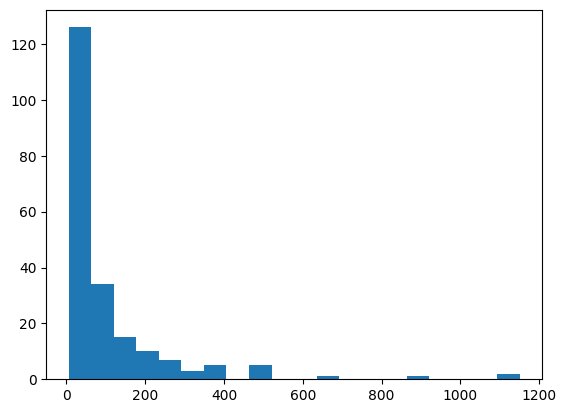

In [9]:
plt.hist(y, bins=20)

Вывод по гистограмме: дисбаланс присутсвует, достаточно большой в сторону значений меньше 200. Значений Больше 200 сильно меньше. Это может вызвать проблемы с предсказанием PRP, тк модель может не обращать внимания на такие данные (выбросы), поэтому это надо учесть при обучении модели и делении данных на train test, а также применять кросс валиацию.

## 3

In [10]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 209 entries, 0 to 208
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   MYCT    209 non-null    int64
 1   MMIN    209 non-null    int64
 2   MMAX    209 non-null    int64
 3   CACH    209 non-null    int64
 4   CHMIN   209 non-null    int64
 5   CHMAX   209 non-null    int64
dtypes: int64(6)
memory usage: 9.9 KB


In [11]:
y.info()

<class 'pandas.core.series.Series'>
RangeIndex: 209 entries, 0 to 208
Series name: class
Non-Null Count  Dtype
--------------  -----
209 non-null    int64
dtypes: int64(1)
memory usage: 1.8 KB


В данных нет пропусков, все значения численные. Можно продолжать работу без рефактора данных.

## 4

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=20, random_state=42, shuffle=True)

In [13]:
model = LinearRegression()
model.fit(X=X_train, y=y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [14]:
model.score(X_train, y_train)

0.833765682163631

In [15]:
model.score(X_test, y_test)

0.8966683891893269

Подсчитывается R^2. Коэффициент детерминации. Показывает долю дисперсии зависимой переменной

## 5

In [16]:
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

In [17]:
MAPE_train = mean_absolute_percentage_error(y_train, y_train_pred)
MAPE_test = mean_absolute_percentage_error(y_test, y_test_pred)
print(f"""
Средняя абсолютная ошибка в процентах на трейне: {MAPE_train}\n
Средняя абсолютная ошибка в процентах на тесте: {MAPE_test}
""")



Средняя абсолютная ошибка в процентах на трейне: 0.6662964698311135

Средняя абсолютная ошибка в процентах на тесте: 0.7317646104403381



Вывод по МАПУ: Ошибка достаточно большая, тк есть дисбаланс и diff между значениями достаточно большой, это сильно влияет на эту метрику

In [18]:
RMSE_train = root_mean_squared_error(y_train, y_train_pred)
RMSE_test = root_mean_squared_error(y_test, y_test_pred)
print(f"""
Корень из среднеквадратичной ошибки на трейне: {RMSE_train}\n
Корень из среднеквадратичной ошибки на тесте: {RMSE_test}
""")



Корень из среднеквадратичной ошибки на трейне: 55.377468695597585

Корень из среднеквадратичной ошибки на тесте: 95.24956305996008



Вывод по РМСЕ: Ошибка достаточно большая и предполагаем что есть проблемы с большими данными как раз из-за дисбаланса и большого штрафа на ольших значениях.

In [ ]:
MedAE_train = median_absolute_error(y_train, y_train_pred)
MedAE_test = median_absolute_error(y_test, y_test_pred)
print(f"""
Медианная абсолютная ошибка на трейне: {MedAE_train}\n
Медианная абсолютная ошибка ошибки на тесте: {MedAE_test}
""")



Медианная абсолютная ошибка на трейне: 23.389781719579766

Медианная абсолютная ошибка ошибки на тесте: 27.886021312484633



Вывод по МАЕ: Ошибка выглядит намного приятнее по сравнению с RMSE и MAPE тк как раз устойчива к выборсам (большым значениям) и лучше работает на дисбалансе

Вывод по 3 метрикам: модель хорошо предсказывает маленькие значения и если выбросы в виде больших значений (>200) редкие, то модель применима

## 6

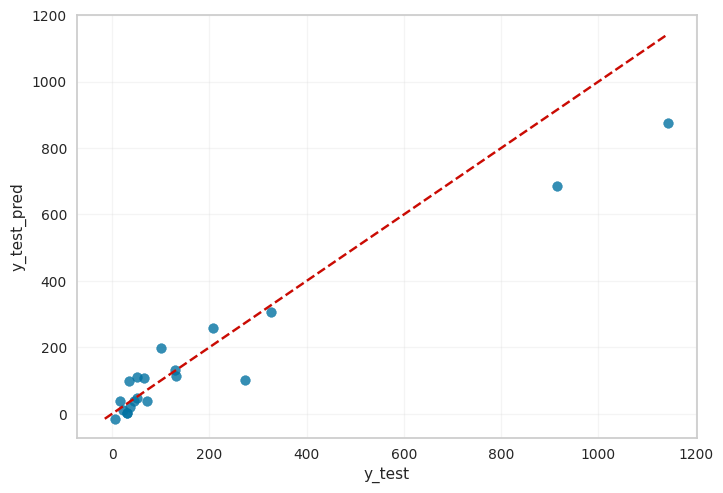

In [78]:
plt.scatter(y_test, y_test_pred, alpha=0.8)
mn, mx = min(y_test.min(), y_test_pred.min()), max(y_test.max(), y_test_pred.max())
plt.plot([mn, mx], [mn, mx], "r--")
plt.xlabel("y_test")
plt.ylabel("y_test_pred")
plt.grid(alpha=0.2)

Визуальное совпадение с теоретическим распределением в области малых значений. На больших значениях факт лучше чем прогноз

## 7

In [21]:
scaler = RobustScaler().fit(X_train)
X_train_scaled = pd.DataFrame(scaler.transform(X_train), columns=X.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X.columns)
X_train_scaled.head()

,MYCT,MMIN,MMAX,CACH,CHMIN,CHMAX
0,1.085714,-0.528302,0.333333,-0.0625,1.0,0.842105
1,0.000000,-0.428816,0.333333,0.2500,0.0,-0.315789
2,-0.342857,0.857633,0.666667,1.7500,0.8,0.105263
3,4.514286,-0.428816,-0.333333,-0.1250,0.0,-0.315789
4,4.514286,-0.638079,-0.583333,-0.2500,0.0,-0.315789


In [22]:
model_sc = LinearRegression()
model_sc.fit(X=X_train_scaled, y=y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [23]:
model_sc.score(X_test_scaled, y_test)

0.8966683891893268

In [24]:
y_train_pred_sc = model_sc.predict(X_train_scaled)
y_test_pred_sc = model_sc.predict(X_test_scaled)

In [25]:
MAPE_train_sc = mean_absolute_percentage_error(y_train, y_train_pred_sc)
MAPE_test_sc = mean_absolute_percentage_error(y_test, y_test_pred_sc)
print(f"""
Средняя абсолютная ошибка в процентах на трейне: {MAPE_train_sc}\n
Средняя абсолютная ошибка в процентах на тесте: {MAPE_test_sc}
""")



Средняя абсолютная ошибка в процентах на трейне: 0.6662964698311131

Средняя абсолютная ошибка в процентах на тесте: 0.7317646104403371



In [26]:
RMSE_train_sc = root_mean_squared_error(y_train, y_train_pred_sc)
RMSE_test_sc = root_mean_squared_error(y_test, y_test_pred_sc)
print(f"""
Корень из среднеквадратичной ошибки на трейне: {RMSE_train_sc}\n
Корень из среднеквадратичной ошибки на тесте: {RMSE_test_sc}
""")



Корень из среднеквадратичной ошибки на трейне: 55.37746869559758

Корень из среднеквадратичной ошибки на тесте: 95.24956305996014



In [ ]:
MedAE_train_sc = median_absolute_error(y_train, y_train_pred_sc)
MedAE_test_sc = median_absolute_error(y_test, y_test_pred_sc)
print(f"""
Медианная абсолютная ошибка на трейне: {MedAE_train_sc}\n
Медианная абсолютная ошибка ошибки на тесте: {MedAE_test_sc}
""")


Медианная абсолютная ошибка на трейне: 23.38978171957968

Медианная абсолютная ошибка ошибки на тесте: 27.88602131248456



In [28]:
print(f"""
До нормализации:
MAPE train: {MAPE_train}
MAPE test: {MAPE_test}

После нормализации:
MAPE train: {MAPE_train_sc}
MAPE test: {MAPE_test_sc}
""")


До нормализации:
MAPE train: 0.6662964698311135
MAPE test: 0.7317646104403381

После нормализации:
MAPE train: 0.6662964698311131
MAPE test: 0.7317646104403371



In [29]:
print(f"""
До нормализации:
RMSE train: {RMSE_train}
RMSE test: {RMSE_test}

После нормализации:
RMSE train: {RMSE_train_sc}
RMSE test: {RMSE_test_sc}
""")


До нормализации:
RMSE train: 55.377468695597585
RMSE test: 95.24956305996008

После нормализации:
RMSE train: 55.37746869559758
RMSE test: 95.24956305996014



In [ ]:
print(f"""
До нормализации:
MedAE train: {MedAE_train}
MedAE test: {MedAE_test}

После нормализации:
MedAE train: {MedAE_train_sc}
MedAE test: {MedAE_test_sc}
""")


До нормализации:
MAE train: 23.389781719579766
MAE test: 27.886021312484633

После нормализации:
MAE train: 23.38978171957968
MAE test: 27.88602131248456



Нормализация практически не повлияла на работу модели, тк линейная регрессия не чувствительна к масштабу признаков.

## 8

In [31]:
model_dt = DecisionTreeRegressor(random_state=42)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(
    model_dt,
    X,
    y,
    cv=kf,
    scoring="neg_root_mean_squared_error"
)

In [32]:
-scores, -np.mean(scores)

(array([96.41295729, 54.56698834, 38.24754894, 62.54170037, 32.73219121]),
 np.float64(56.900277231975224))

## 9

In [ ]:
mpl.rcParams["font.family"] = "sans-serif"
mpl.rcParams["font.sans-serif"] = ["DejaVu Sans"]  

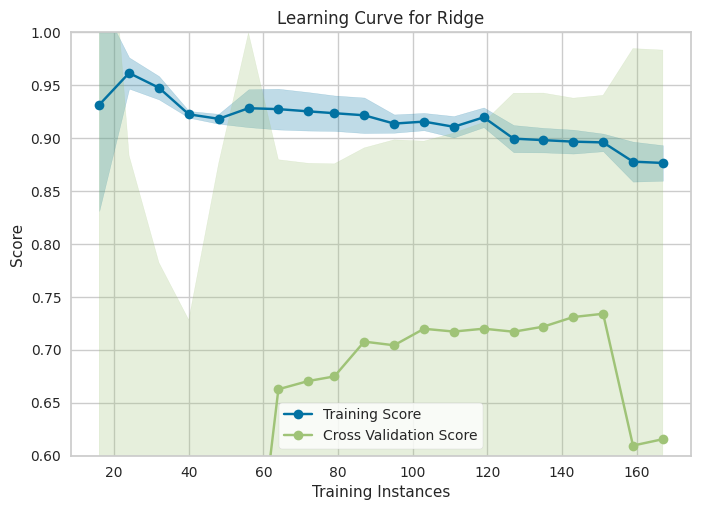

<Axes: title={'center': 'Learning Curve for Ridge'}, xlabel='Training Instances', ylabel='Score'>

In [46]:
visuilizer = LearningCurve(Ridge(), train_sizes=np.linspace(0.1, 1.0, 20))

visuilizer.fit(X,y)
plt.ylim(0.6,1)
visuilizer.show()

Вывод по графику обучения: Модель переобучилась, слишком высокий score (около 0.9-0.95) говорит о том что модель подстроилась под данные + cv score находится достаточно низко (gap ~ 0.2-0.3), т.е на val она работает плохо и хуже чем на трейне.

## 10

In [90]:
alphas = np.linspace(1, 1000, 100)

param_grid = {
    "alpha": alphas
}

grid = GridSearchCV(
    estimator=Ridge(),
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    return_train_score=True
)

grid.fit(X_train, y_train)

,estimator,Ridge()
,param_grid,{'alpha': array([ 1. ...000. ])}
,scoring,'r2'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,alpha,np.float64(1000.0)


In [91]:
results = pd.DataFrame(grid.cv_results_)

results[['param_alpha', 'mean_train_score', 'mean_test_score', 'rank_test_score']]

,param_alpha,mean_train_score,mean_test_score,rank_test_score
0,1.000000,0.844348,0.715489,100
1,11.090909,0.844348,0.715568,99
2,21.181818,0.844348,0.715647,98
3,31.272727,0.844347,0.715725,97
4,41.363636,0.844347,0.715803,96
...,...,...,...,...
95,959.636364,0.844100,0.721211,5
96,969.727273,0.844096,0.721257,4
97,979.818182,0.844092,0.721303,3
98,989.909091,0.844088,0.721349,2


In [92]:
best_model = grid.best_estimator_
best_model

,alpha,np.float64(1000.0)
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [93]:
best_model.score(X_test, y_test)

0.8961987002690791